# NeRF from COLMAP Reconstruction

Train a NeRFwith hierarchical sampling directly from camera poses and sparse point cloud produced by a **COLMAP SfM pipeline**.

### Pipeline overview
1. **Setup** – imports, device selection, path configuration
2. **Architecture** – Positional Encoding, NeRF MLP, volume rendering helpers
3. **Load COLMAP** – read binary model and explore camera poses
4. **Build dataset** – load images, build ray batch, compute near/far from point cloud
5. **Train** – coarse-to-fine training loop with periodic validation previews
6. **Render** – synthesise a 360° flyaround video and depth video

## 1. Setup

In [1]:
import sys
import os
from pathlib import Path

# Make the utils/ folder importable
REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT / "utils"))

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from tqdm import tqdm, trange
import imageio
import time
import cv2

from colmap import load_colmap_bin_model

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Using device: cuda


## 2. Configuration

Set paths and hyper-parameters here.  
`SCALE_FACTOR` trades image resolution for speed (`0.5` → 2× faster).  
`N_RAND` is the batch size (rays per training step).  
`N_SAMPLES` / `N_IMPORTANCE` are coarse and fine depth samples per ray.

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
COLMAP_DIR = str(REPO_ROOT / "results" / "colmap_miniature" / "0")
IMAGE_DIR  = str(REPO_ROOT / "data" / "images" / "miniature")
OUTPUT_DIR = str(REPO_ROOT / "results" / "nerf_miniature")

# ── Image scale ───────────────────────────────────────────────────────────────
SCALE_FACTOR = 0.5          # resize images (< 1 = faster training)
WHITE_BG     = False         # True for objects on white / transparent BGs

# ── Training ──────────────────────────────────────────────────────────────────
N_ITERS      = 70_000        # total training steps
N_RAND       = 1024          # rays per training step (batch size)
LRATE        = 5e-4          # initial learning rate
LRATE_DECAY  = 250           # lr decay in thousands of steps (like original paper)
N_SAMPLES    = 64            # coarse depth samples per ray
N_IMPORTANCE = 128           # fine (hierarchical) depth samples per ray
USE_VIEWDIRS = True          # condition colour on viewing direction
NETDEPTH     = 8             # coarse MLP layers
NETWIDTH     = 256           # coarse MLP width
NETDEPTH_F   = 8             # fine MLP layers
NETWIDTH_F   = 256           # fine MLP width
NETCHUNK     = 1024 * 64     # network query chunk size
CHUNK        = 1024 * 32     # ray batch chunk size during rendering
PERTURB      = 1.0           # stratified sampling jitter (0 = off)
RAW_NOISE_STD = 0.0          # density noise during training
I_PRINT      = 500           # log every N steps
I_PREVIEW    = 5_000         # render a preview every N steps (0 = off)
PREVIEW_IDX  = 0             # which training image to use as validation preview

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Config ready.")

Config ready.


---

## 3. NeRF Architecture

Define the core components directly from `nerf-pytorch.py`:
- **Embedder / `get_embedder`** – Fourier positional encoding for positions and view directions
- **`NeRF` MLP** – 8-layer MLP (D=8, W=256) with skip connection at layer 4, view-direction head
- **Volume rendering helpers** – `raw2outputs`, `render_rays`, `render`, `render_path`

In [3]:
# ── Misc helpers ──────────────────────────────────────────────────────────────
img2mse  = lambda x, y: torch.mean((x - y) ** 2)
mse2psnr = lambda x: -10. * torch.log10(x)
to8b     = lambda x: (255 * np.clip(x, 0, 1)).astype(np.uint8)

# ── Positional encoding (Sec. 5.1) ────────────────────────────────────────────
class Embedder:
    def __init__(self, **kwargs):
        self.kwargs = kwargs
        self.create_embedding_fn()

    def create_embedding_fn(self):
        embed_fns = []
        d = self.kwargs['input_dims']
        out_dim = 0
        if self.kwargs['include_input']:
            embed_fns.append(lambda x: x)
            out_dim += d

        max_freq = self.kwargs['max_freq_log2']
        N_freqs  = self.kwargs['num_freqs']
        if self.kwargs['log_sampling']:
            freq_bands = 2. ** torch.linspace(0., max_freq, steps=N_freqs)
        else:
            freq_bands = torch.linspace(2.**0., 2.**max_freq, steps=N_freqs)

        for freq in freq_bands:
            for p_fn in self.kwargs['periodic_fns']:
                embed_fns.append(lambda x, p_fn=p_fn, freq=freq: p_fn(x * freq))
                out_dim += d

        self.embed_fns = embed_fns
        self.out_dim   = out_dim

    def embed(self, inputs):
        return torch.cat([fn(inputs) for fn in self.embed_fns], -1)


def get_embedder(multires, i=0):
    if i == -1:
        return nn.Identity(), 3
    embed_kwargs = {
        'include_input'  : True,
        'input_dims'     : 3,
        'max_freq_log2'  : multires - 1,
        'num_freqs'      : multires,
        'log_sampling'   : True,
        'periodic_fns'   : [torch.sin, torch.cos],
    }
    embedder_obj = Embedder(**embed_kwargs)
    embed = lambda x, eo=embedder_obj: eo.embed(x)
    return embed, embedder_obj.out_dim

print("Embedder defined.")

# ── NeRF MLP ──────────────────────────────────────────────────────────────────
class NeRF(nn.Module):
    def __init__(self, D=8, W=256, input_ch=3, input_ch_views=3, output_ch=4,
                 skips=[4], use_viewdirs=False):
        super().__init__()
        self.D = D; self.W = W
        self.input_ch = input_ch; self.input_ch_views = input_ch_views
        self.skips = skips; self.use_viewdirs = use_viewdirs

        self.pts_linears = nn.ModuleList(
            [nn.Linear(input_ch, W)] +
            [nn.Linear(W, W) if i not in skips else nn.Linear(W + input_ch, W)
             for i in range(D - 1)]
        )
        self.views_linears = nn.ModuleList([nn.Linear(input_ch_views + W, W // 2)])

        if use_viewdirs:
            self.feature_linear = nn.Linear(W, W)
            self.alpha_linear   = nn.Linear(W, 1)
            self.rgb_linear     = nn.Linear(W // 2, 3)
        else:
            self.output_linear  = nn.Linear(W, output_ch)

    def forward(self, x):
        input_pts, input_views = torch.split(x, [self.input_ch, self.input_ch_views], dim=-1)
        h = input_pts
        for i, l in enumerate(self.pts_linears):
            h = F.relu(self.pts_linears[i](h))
            if i in self.skips:
                h = torch.cat([input_pts, h], -1)

        if self.use_viewdirs:
            alpha   = self.alpha_linear(h)
            feature = self.feature_linear(h)
            h       = torch.cat([feature, input_views], -1)
            for l in self.views_linears:
                h = F.relu(l(h))
            rgb     = self.rgb_linear(h)
            outputs = torch.cat([rgb, alpha], -1)
        else:
            outputs = self.output_linear(h)
        return outputs

print("NeRF MLP defined.")

Embedder defined.
NeRF MLP defined.


In [14]:
# ── Misc helpers ──────────────────────────────────────────────────────────────
img2mse  = lambda x, y: torch.mean((x - y) ** 2)
mse2psnr = lambda x: -10. * torch.log10(x)
to8b     = lambda x: (255 * np.clip(x, 0, 1)).astype(np.uint8)

class HashEncoding(nn.Module):
    """Multi-resolution hash encoding for Instant NGP"""
    
    def __init__(self, 
                 n_levels: int = 16,
                 n_features_per_level: int = 2,
                 log2_hashmap_size: int = 19,
                 base_resolution: int = 16,
                 finest_resolution: int = 512):
        super().__init__()
        self.n_levels = n_levels
        self.n_features_per_level = n_features_per_level
        self.log2_hashmap_size = log2_hashmap_size
        self.base_resolution = base_resolution
        self.finest_resolution = finest_resolution
        
        # Growth factor between levels
        self.b = np.exp((np.log(finest_resolution) - np.log(base_resolution)) / (n_levels - 1))
        
        # Hash tables for each level
        self.embeddings = nn.ModuleList([
            nn.Embedding(2 ** log2_hashmap_size, n_features_per_level)
            for _ in range(n_levels)
        ])
        
        # Initialize embeddings
        for emb in self.embeddings:
            nn.init.uniform_(emb.weight, -1e-4, 1e-4)
    
    def forward(self, x):
        """
        Args:
            x: [..., 3] input coordinates in range [-1, 1]
        Returns:
            [..., n_levels * n_features_per_level] encoded features
        """
        # Normalize to [0, 1]
        x = (x + 1) / 2
        
        # Clamp to valid range
        x = torch.clamp(x, 0, 1)
        
        encoded = []
        for level in range(self.n_levels):
            resolution = int(self.base_resolution * (self.b ** level))
            
            # Scale coordinates to grid resolution
            scaled = x * (resolution - 1)
            
            # Get grid cell corners (trilinear interpolation)
            grid_coords = torch.floor(scaled).long()
            weights = scaled - grid_coords.float()
            
            # Hash function (simple but effective)
            def hash_func(coords):
                # Ensure coords are in valid range
                coords = coords % resolution
                # Simple hash: XOR of prime-scaled coordinates
                primes = torch.tensor([1, 2654435761, 805459861], device=coords.device, dtype=torch.long)
                hashed = torch.zeros(coords.shape[0], device=coords.device, dtype=torch.long)
                for i in range(3):
                    hashed ^= coords[:, i] * primes[i]
                return hashed % (2 ** self.log2_hashmap_size)
            
            # Trilinear interpolation over 8 corners
            features = torch.zeros(x.shape[0], self.n_features_per_level, device=x.device)
            for i in range(2):
                for j in range(2):
                    for k in range(2):
                        corner = grid_coords.clone()
                        corner[:, 0] += i
                        corner[:, 1] += j
                        corner[:, 2] += k
                        
                        # Get hash indices
                        hashed_indices = hash_func(corner)
                        
                        # Get features from hash table
                        corner_features = self.embeddings[level](hashed_indices)
                        
                        # Compute interpolation weight
                        w = (weights[:, 0] if i == 1 else (1 - weights[:, 0])) * \
                            (weights[:, 1] if j == 1 else (1 - weights[:, 1])) * \
                            (weights[:, 2] if k == 1 else (1 - weights[:, 2]))
                        
                        features += corner_features * w.unsqueeze(-1)
            
            encoded.append(features)
        
        return torch.cat(encoded, dim=-1)


class PositionalEncoding(nn.Module):
    """Positional encoding for directions (still used for view directions)"""
    
    def __init__(self, num_freqs: int = 4):
        super().__init__()
        self.num_freqs = num_freqs
        freq_bands = 2.0 ** torch.linspace(0, num_freqs-1, num_freqs)
        self.register_buffer('freq_bands', freq_bands)
    
    def forward(self, x):
        """
        Args:
            x: [..., C] input coordinates
        Returns:
            [..., C * (2*num_freqs + 1)] encoded coordinates
        """
        out = [x]
        for freq in self.freq_bands:
            out.append(torch.sin(freq * x))
            out.append(torch.cos(freq * x))
        return torch.cat(out, dim=-1)


class SimpleNeRF(nn.Module):
    """Instant NGP network with hash encoding"""
    
    def __init__(self, 
                 n_levels: int = 16,
                 n_features_per_level: int = 2,
                 log2_hashmap_size: int = 19,
                 base_resolution: int = 16,
                 finest_resolution: int = 512,
                 dir_enc_freqs: int = 4,
                 hidden_dim: int = 64):
        super().__init__()
        
        # Use hash encoding for positions (Instant NGP)
        self.pos_encoding = HashEncoding(
            n_levels=n_levels,
            n_features_per_level=n_features_per_level,
            log2_hashmap_size=log2_hashmap_size,
            base_resolution=base_resolution,
            finest_resolution=finest_resolution
        )
        
        # Use positional encoding for directions
        self.dir_encoding = PositionalEncoding(dir_enc_freqs)
        
        pos_enc_dim = n_levels * n_features_per_level
        dir_enc_dim = 3 * (2 * dir_enc_freqs + 1)
        
        # Density network (smaller and faster for Instant NGP)
        self.density_net = nn.Sequential(
            nn.Linear(pos_enc_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim + 1)  # +1 for density
        )
        
        # Color network
        self.color_net = nn.Sequential(
            nn.Linear(hidden_dim + dir_enc_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 3),
            nn.Sigmoid()
        )
    
    def forward(self, positions, directions):
        """
        Args:
            positions: [N, 3] 3D positions
            directions: [N, 3] view directions
        Returns:
            colors: [N, 3] RGB colors
            densities: [N, 1] volume densities
        """
        # Encode positions
        pos_enc = self.pos_encoding(positions)
        
        # Get features and density
        features = self.density_net(pos_enc)
        # Use softplus for density (allows gradients to flow, standard in NeRF)
        density = F.softplus(features[..., :1] - 1.0)  # -1 bias for initialization
        feature_vec = features[..., 1:]
        
        # Encode directions
        dir_enc = self.dir_encoding(directions)
        
        # Get color
        color_input = torch.cat([feature_vec, dir_enc], dim=-1)
        color = self.color_net(color_input)
        
        return color, density

In [4]:
# ── Ray helpers ───────────────────────────────────────────────────────────────
def get_rays(H, W, K, c2w):
    dev = c2w.device
    i, j = torch.meshgrid(torch.linspace(0, W-1, W, device=dev), torch.linspace(0, H-1, H, device=dev))
    i = i.t(); j = j.t()
    dirs   = torch.stack([(i - K[0][2]) / K[0][0],
                          -(j - K[1][2]) / K[1][1],
                          -torch.ones_like(i)], -1)
    rays_d = torch.sum(dirs[..., None, :] * c2w[:3, :3], -1)
    rays_o = c2w[:3, -1].expand(rays_d.shape)
    return rays_o, rays_d


def get_rays_np(H, W, K, c2w):
    i, j = np.meshgrid(np.arange(W, dtype=np.float32),
                       np.arange(H, dtype=np.float32), indexing='xy')
    dirs   = np.stack([(i - K[0][2]) / K[0][0],
                       -(j - K[1][2]) / K[1][1],
                       -np.ones_like(i)], -1)
    rays_d = np.sum(dirs[..., None, :] * c2w[:3, :3], -1)
    rays_o = np.broadcast_to(c2w[:3, -1], np.shape(rays_d))
    return rays_o, rays_d


# ── Hierarchical sampling (Sec. 5.2) ─────────────────────────────────────────
def sample_pdf(bins, weights, N_samples, det=False):
    weights = weights + 1e-5
    pdf  = weights / torch.sum(weights, -1, keepdim=True)
    cdf  = torch.cumsum(pdf, -1)
    cdf  = torch.cat([torch.zeros_like(cdf[..., :1]), cdf], -1)

    if det:
        u = torch.linspace(0., 1., steps=N_samples, device=bins.device)
        u = u.expand(list(cdf.shape[:-1]) + [N_samples])
    else:
        u = torch.rand(list(cdf.shape[:-1]) + [N_samples], device=bins.device)

    u = u.contiguous()
    inds  = torch.searchsorted(cdf, u, right=True)
    below = torch.max(torch.zeros_like(inds - 1), inds - 1)
    above = torch.min((cdf.shape[-1] - 1) * torch.ones_like(inds), inds)
    inds_g = torch.stack([below, above], -1)

    matched_shape = [inds_g.shape[0], inds_g.shape[1], cdf.shape[-1]]
    cdf_g  = torch.gather(cdf.unsqueeze(1).expand(matched_shape), 2, inds_g)
    bins_g = torch.gather(bins.unsqueeze(1).expand(matched_shape), 2, inds_g)

    denom   = (cdf_g[..., 1] - cdf_g[..., 0])
    denom   = torch.where(denom < 1e-5, torch.ones_like(denom), denom)
    t       = (u - cdf_g[..., 0]) / denom
    samples = bins_g[..., 0] + t * (bins_g[..., 1] - bins_g[..., 0])
    return samples


# ── Network query helpers ──────────────────────────────────────────────────────
def batchify(fn, chunk):
    if chunk is None:
        return fn
    def ret(inputs):
        return torch.cat([fn(inputs[i:i+chunk]) for i in range(0, inputs.shape[0], chunk)], 0)
    return ret


def run_network(inputs, viewdirs, fn, embed_fn, embeddirs_fn, netchunk=1024*64):
    inputs_flat = torch.reshape(inputs, [-1, inputs.shape[-1]])
    embedded    = embed_fn(inputs_flat)
    if viewdirs is not None:
        input_dirs      = viewdirs[:, None].expand(inputs.shape)
        input_dirs_flat = torch.reshape(input_dirs, [-1, input_dirs.shape[-1]])
        embedded_dirs   = embeddirs_fn(input_dirs_flat)
        embedded        = torch.cat([embedded, embedded_dirs], -1)
    outputs_flat = batchify(fn, netchunk)(embedded)
    outputs = torch.reshape(outputs_flat, list(inputs.shape[:-1]) + [outputs_flat.shape[-1]])
    return outputs

print("Ray helpers defined.")

Ray helpers defined.


In [5]:
# ── Volume rendering ──────────────────────────────────────────────────────────
def raw2outputs(raw, z_vals, rays_d, raw_noise_std=0, white_bkgd=False):
    raw2alpha = lambda raw, dists, act_fn=F.relu: 1. - torch.exp(-act_fn(raw) * dists)

    dists = z_vals[..., 1:] - z_vals[..., :-1]
    dists = torch.cat([dists, torch.full(dists[..., :1].shape, 1e10, device=dists.device)], -1)
    dists = dists * torch.norm(rays_d[..., None, :], dim=-1)

    rgb   = torch.sigmoid(raw[..., :3])
    noise = 0.
    if raw_noise_std > 0.:
        noise = torch.randn(raw[..., 3].shape, device=raw.device) * raw_noise_std

    alpha    = raw2alpha(raw[..., 3] + noise, dists)
    weights  = alpha * torch.cumprod(
        torch.cat([torch.ones((alpha.shape[0], 1), device=alpha.device), 1. - alpha + 1e-10], -1), -1)[:, :-1]
    rgb_map  = torch.sum(weights[..., None] * rgb, -2)

    depth_map = torch.sum(weights * z_vals, -1)
    disp_map  = 1. / torch.max(1e-10 * torch.ones_like(depth_map),
                               depth_map / torch.sum(weights, -1))
    acc_map = torch.sum(weights, -1)

    if white_bkgd:
        rgb_map = rgb_map + (1. - acc_map[..., None])

    return rgb_map, disp_map, acc_map, weights, depth_map


def render_rays(ray_batch, network_fn, network_query_fn,
                N_samples, retraw=False, lindisp=False, perturb=0.,
                N_importance=0, network_fine=None,
                white_bkgd=False, raw_noise_std=0., **kwargs):
    dev      = ray_batch.device
    N_rays   = ray_batch.shape[0]
    rays_o   = ray_batch[:, 0:3]
    rays_d   = ray_batch[:, 3:6]
    viewdirs = ray_batch[:, -3:] if ray_batch.shape[-1] > 8 else None
    bounds   = torch.reshape(ray_batch[..., 6:8], [-1, 1, 2])
    near, far = bounds[..., 0], bounds[..., 1]

    t_vals = torch.linspace(0., 1., steps=N_samples, device=dev)
    if not lindisp:
        z_vals = near * (1. - t_vals) + far * t_vals
    else:
        z_vals = 1. / (1. / near * (1. - t_vals) + 1. / far * t_vals)
    z_vals = z_vals.expand([N_rays, N_samples])

    if perturb > 0.:
        mids  = .5 * (z_vals[..., 1:] + z_vals[..., :-1])
        upper = torch.cat([mids, z_vals[..., -1:]], -1)
        lower = torch.cat([z_vals[..., :1], mids], -1)
        t_rand = torch.rand(z_vals.shape, device=dev)
        z_vals = lower + (upper - lower) * t_rand

    pts = rays_o[..., None, :] + rays_d[..., None, :] * z_vals[..., :, None]
    raw = network_query_fn(pts, viewdirs, network_fn)
    rgb_map, disp_map, acc_map, weights, depth_map = raw2outputs(
        raw, z_vals, rays_d, raw_noise_std, white_bkgd)

    if N_importance > 0:
        rgb_map_0, disp_map_0, acc_map_0 = rgb_map, disp_map, acc_map
        z_vals_mid = .5 * (z_vals[..., 1:] + z_vals[..., :-1])
        z_samples  = sample_pdf(z_vals_mid, weights[..., 1:-1], N_importance,
                                det=(perturb == 0.))
        z_samples  = z_samples.detach()
        z_vals, _  = torch.sort(torch.cat([z_vals, z_samples], -1), -1)
        pts = rays_o[..., None, :] + rays_d[..., None, :] * z_vals[..., :, None]
        run_fn = network_fn if network_fine is None else network_fine
        raw    = network_query_fn(pts, viewdirs, run_fn)
        rgb_map, disp_map, acc_map, weights, depth_map = raw2outputs(
            raw, z_vals, rays_d, raw_noise_std, white_bkgd)

    ret = {'rgb_map': rgb_map, 'disp_map': disp_map, 'acc_map': acc_map}
    if retraw:
        ret['raw'] = raw
    if N_importance > 0:
        ret['rgb0']  = rgb_map_0
        ret['disp0'] = disp_map_0
        ret['acc0']  = acc_map_0
        ret['z_std'] = torch.std(z_samples, dim=-1, unbiased=False)
    return ret


def batchify_rays(rays_flat, chunk=1024*32, **kwargs):
    all_ret = {}
    for i in range(0, rays_flat.shape[0], chunk):
        ret = render_rays(rays_flat[i:i+chunk], **kwargs)
        for k in ret:
            if k not in all_ret:
                all_ret[k] = []
            all_ret[k].append(ret[k])
    all_ret = {k: torch.cat(all_ret[k], 0) for k in all_ret}
    return all_ret


def render(H, W, K, chunk=1024*32, rays=None, c2w=None,
           near=0., far=1., use_viewdirs=False, **kwargs):
    if c2w is not None:
        rays_o, rays_d = get_rays(H, W, K, c2w)
    else:
        rays_o, rays_d = rays

    if use_viewdirs:
        viewdirs = rays_d / torch.norm(rays_d, dim=-1, keepdim=True)
        viewdirs = torch.reshape(viewdirs, [-1, 3]).float()

    sh     = rays_d.shape
    rays_o = torch.reshape(rays_o, [-1, 3]).float()
    rays_d = torch.reshape(rays_d, [-1, 3]).float()
    near_  = near * torch.ones_like(rays_d[..., :1])
    far_   = far  * torch.ones_like(rays_d[..., :1])
    rays   = torch.cat([rays_o, rays_d, near_, far_], -1)
    if use_viewdirs:
        rays = torch.cat([rays, viewdirs], -1)

    all_ret = batchify_rays(rays, chunk, **kwargs)
    for k in all_ret:
        k_sh = list(sh[:-1]) + list(all_ret[k].shape[1:])
        all_ret[k] = torch.reshape(all_ret[k], k_sh)

    k_extract = ['rgb_map', 'disp_map', 'acc_map']
    ret_list = [all_ret[k] for k in k_extract]
    ret_dict = {k: all_ret[k] for k in all_ret if k not in k_extract}
    return ret_list + [ret_dict]


def render_path(render_poses, hwf, K, chunk, render_kwargs,
                gt_imgs=None, savedir=None, render_factor=0):
    H, W, focal = hwf
    if render_factor != 0:
        H = H // render_factor
        W = W // render_factor
        focal = focal / render_factor

    rgbs, disps = [], []
    t = time.time()
    for i, c2w in enumerate(tqdm(render_poses, desc="Rendering")):
        rgb, disp, acc, _ = render(H, W, K, chunk=chunk, c2w=c2w[:3, :4], **render_kwargs)
        rgbs.append(rgb.cpu().numpy())
        disps.append(disp.cpu().numpy())
        if savedir is not None:
            imageio.imwrite(os.path.join(savedir, f'{i:03d}.png'), to8b(rgbs[-1]))
    return np.stack(rgbs, 0), np.stack(disps, 0)

print("Volume rendering helpers defined.")

Volume rendering helpers defined.


## 4. Load COLMAP Model & Explore Poses

In [6]:
cams_dict, images_dict, points_dict = load_colmap_bin_model(COLMAP_DIR)

print(f"Cameras  : {len(cams_dict)}")
print(f"Images   : {len(images_dict)}")
print(f"3-D pts  : {len(points_dict)}")

# Helper: COLMAP quaternion (qw, qx, qy, qz) → 3×3 rotation matrix
def qvec_to_rotmat(qvec):
    qw, qx, qy, qz = qvec
    return np.array([
        [1 - 2*(qy**2 + qz**2),   2*(qx*qy - qz*qw),   2*(qx*qz + qy*qw)],
        [2*(qx*qy + qz*qw),   1 - 2*(qx**2 + qz**2),   2*(qy*qz - qx*qw)],
        [2*(qx*qz - qy*qw),       2*(qy*qz + qx*qw), 1 - 2*(qx**2 + qy**2)],
    ], dtype=float)


def colmap_to_c2w(qvec, tvec):
    """COLMAP world-to-camera → camera-to-world 4×4 matrix."""
    R_cw = qvec_to_rotmat(qvec)
    t    = np.asarray(tvec, dtype=float)
    c2w  = np.eye(4, dtype=float)
    c2w[:3, :3] = R_cw.T
    c2w[:3,  3] = -(R_cw.T @ t)
    return c2w


def colmap_intrinsics(cam):
    model  = cam["model"].upper()
    params = cam["params"]
    W, H   = cam["width"], cam["height"]
    if model == "SIMPLE_PINHOLE":
        fx = fy = params[0]; cx = params[1]; cy = params[2]
    elif model == "PINHOLE":
        fx = params[0]; fy = params[1]; cx = params[2]; cy = params[3]
    elif model in {"SIMPLE_RADIAL", "RADIAL"}:
        fx = fy = params[0]; cx = params[1]; cy = params[2]
    else:
        fx = fy = max(W, H) * 1.2; cx = W / 2; cy = H / 2
    return np.array([[fx, 0, cx], [0, fy, cy], [0, 0, 1]], dtype=float)


for cam_id, cam in cams_dict.items():
    K = colmap_intrinsics(cam)
    print(f"\n  Camera {cam_id}: {cam['model']}  {cam['width']}×{cam['height']}")
    print(f"    fx={K[0,0]:.1f}  fy={K[1,1]:.1f}  cx={K[0,2]:.1f}  cy={K[1,2]:.1f}")

Cameras  : 103
Images   : 103
3-D pts  : 20838

  Camera 1: SIMPLE_RADIAL  1920×1080
    fx=3110.2  fy=3110.2  cx=960.0  cy=540.0

  Camera 2: SIMPLE_RADIAL  1920×1080
    fx=3119.3  fy=3119.3  cx=960.0  cy=540.0

  Camera 3: SIMPLE_RADIAL  1920×1080
    fx=3143.5  fy=3143.5  cx=960.0  cy=540.0

  Camera 4: SIMPLE_RADIAL  1920×1080
    fx=3123.3  fy=3123.3  cx=960.0  cy=540.0

  Camera 5: SIMPLE_RADIAL  1920×1080
    fx=3123.9  fy=3123.9  cx=960.0  cy=540.0

  Camera 6: SIMPLE_RADIAL  1920×1080
    fx=3119.1  fy=3119.1  cx=960.0  cy=540.0

  Camera 7: SIMPLE_RADIAL  1920×1080
    fx=3133.8  fy=3133.8  cx=960.0  cy=540.0

  Camera 8: SIMPLE_RADIAL  1920×1080
    fx=3138.0  fy=3138.0  cx=960.0  cy=540.0

  Camera 9: SIMPLE_RADIAL  1920×1080
    fx=3114.0  fy=3114.0  cx=960.0  cy=540.0

  Camera 10: SIMPLE_RADIAL  1920×1080
    fx=3113.2  fy=3113.2  cx=960.0  cy=540.0

  Camera 11: SIMPLE_RADIAL  1920×1080
    fx=3125.1  fy=3125.1  cx=960.0  cy=540.0

  Camera 12: SIMPLE_RADIAL  1920×1080

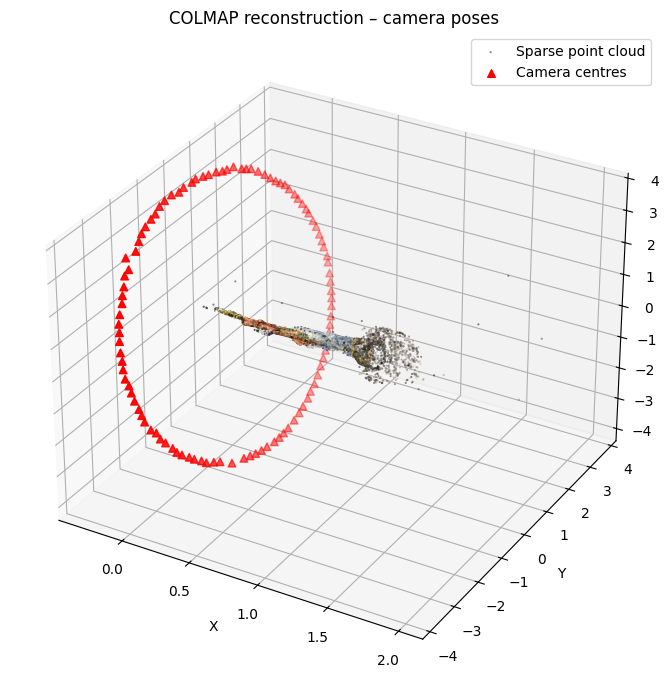


Scene centre : [ 0.00179258 -0.00638008 -0.02248126]
Scene radius : 3.8700


In [8]:
# ── Visualise camera centres + sparse point cloud ────────────────────────────
c2w_mats = {img_id: colmap_to_c2w(info["qvec"], info["tvec"])
            for img_id, info in images_dict.items()}
cam_centers = np.stack([m[:3, 3] for m in c2w_mats.values()])

fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection="3d")

if points_dict:
    rng = np.random.default_rng(0)
    pts  = np.stack([v["xyz"] for v in points_dict.values()])
    cols = np.stack([v["rgb"] for v in points_dict.values()]) / 255.0
    idx  = rng.choice(len(pts), min(8_000, len(pts)), replace=False)
    ax.scatter(pts[idx, 0], pts[idx, 1], pts[idx, 2],
               c=cols[idx], s=0.3, alpha=0.5, label="Sparse point cloud")

ax.scatter(cam_centers[:, 0], cam_centers[:, 1], cam_centers[:, 2],
           c="red", s=30, marker="^", zorder=5, label="Camera centres")
ax.set_title("COLMAP reconstruction – camera poses")
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
ax.legend()
plt.tight_layout()
plt.show()

scene_center = cam_centers.mean(axis=0)
scene_scale  = np.linalg.norm(cam_centers - scene_center, axis=-1).max()
print(f"\nScene centre : {scene_center}")
print(f"Scene radius : {scene_scale:.4f}")

## 5. Build Dataset

Load images, build per-image intrinsics, normalise the scene into a unit sphere, compute near/far planes from the sparse point cloud, and pre-build the full ray batch (rays_rgb) used during training.


Images loaded : 103  |  H=960  W=540  focal=1555.1
Near=0.0456  Far=0.4340


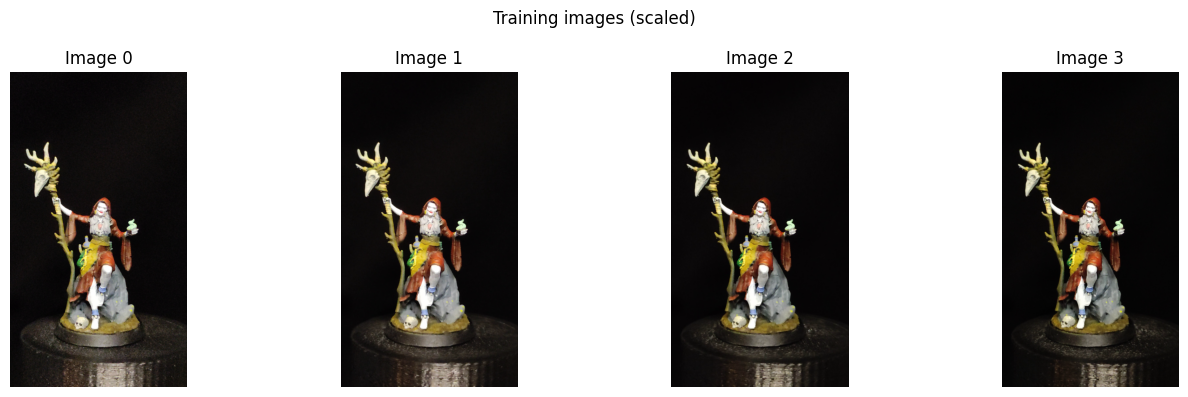

In [9]:
from PIL import Image as PILImage
from PIL import ImageOps

# ── Sort images by name for a stable ordering ─────────────────────────────────
sorted_img_ids = sorted(images_dict.keys(), key=lambda k: images_dict[k]["name"])

# ── Load images & build per-frame intrinsics / c2w ───────────────────────────
imgs_list, c2w_list, K_list = [], [], []

for img_id in sorted_img_ids:
    info   = images_dict[img_id]
    cam    = cams_dict[info["camera_id"]]

    # Intrinsics (scaled)
    K_full = colmap_intrinsics(cam)
    orig_W, orig_H = cam["width"], cam["height"]
    new_W  = int(orig_W * SCALE_FACTOR)
    new_H  = int(orig_H * SCALE_FACTOR)
    sx     = new_W / orig_W
    sy     = new_H / orig_H
    K_scaled = K_full.copy()
    K_scaled[0] *= sx; K_scaled[1] *= sy

    # Camera-to-world
    c2w = colmap_to_c2w(info["qvec"], info["tvec"])

    # Image
    img_path = os.path.join(IMAGE_DIR, info["name"])
    img = PILImage.open(img_path)
    img = ImageOps.exif_transpose(img)              # respect EXIF orientation
    orig_W, orig_H = img.size                        # width, height from actual file
    new_W = int(orig_W * SCALE_FACTOR)
    new_H = int(orig_H * SCALE_FACTOR)
    img = img.resize((new_W, new_H), PILImage.LANCZOS)
    img_np = np.array(img, dtype=np.float32) / 255.0

    imgs_list.append(img_np)
    c2w_list.append(c2w)
    K_list.append(K_scaled)

N      = len(imgs_list)
H, W   = imgs_list[0].shape[:2]
focal  = K_list[0][0, 0]
hwf    = [H, W, focal]

# Stack
images = np.stack(imgs_list,  0).astype(np.float32)   # (N, H, W, 3)
poses  = np.stack(c2w_list,   0).astype(np.float32)   # (N, 4, 4)
Ks     = np.stack(K_list,     0).astype(np.float32)   # (N, 3, 3)

# ── Scene normalisation ───────────────────────────────────────────────────────
cam_centers_all = poses[:, :3, 3]
scene_center    = cam_centers_all.mean(axis=0)
scene_scale     = np.linalg.norm(cam_centers_all - scene_center, axis=-1).max()

# Translate so scene centre = origin, scale so cameras fit in unit sphere
poses[:, :3, 3] = (poses[:, :3, 3] - scene_center) / scene_scale
Ks_norm         = Ks.copy()   # intrinsics unchanged by scene normalisation

# ── near / far from sparse point cloud ───────────────────────────────────────
if points_dict:
    pts_world = np.stack([v["xyz"] for v in points_dict.values()])
    pts_norm  = (pts_world - scene_center) / scene_scale
    dists     = np.linalg.norm(pts_norm, axis=-1)
    near      = float(max(0.01, np.percentile(dists, 1) * 0.8))
    far       = float(np.percentile(dists, 99) * 1.2)
else:
    near, far = 0.1, 4.0

print(f"\nImages loaded : {N}  |  H={H}  W={W}  focal={focal:.1f}")
print(f"Near={near:.4f}  Far={far:.4f}")

# ── Show first few training images ────────────────────────────────────────────
N_show = min(4, N)
fig, axes = plt.subplots(1, N_show, figsize=(14, 4))
if N_show == 1:
    axes = [axes]
for ax, idx in zip(axes, range(N_show)):
    ax.imshow(images[idx].clip(0, 1))
    ax.set_title(f"Image {idx}")
    ax.axis("off")
plt.suptitle("Training images (scaled)")
plt.tight_layout(); plt.show()

In [10]:
# ── Build shuffled ray batch (rays_rgb) ──────────────────────────────────────
# Uses K_list[0] (common intrinsics after scaling) as per the single-camera case.
# For per-image intrinsics, adapt by building rays per-image and concatenating.
K_np = Ks_norm[0]

print("Building ray batch …")
rays = np.stack([get_rays_np(H, W, K_np, p[:3, :4]) for p in poses], 0)  # (N, 2, H, W, 3)
rays_rgb = np.concatenate([rays, images[:, None]], 1)                      # (N, 3, H, W, 3)
rays_rgb = np.transpose(rays_rgb, [0, 2, 3, 1, 4])                        # (N, H, W, 3, 3)
rays_rgb = np.reshape(rays_rgb, [-1, 3, 3]).astype(np.float32)             # (N*H*W, 3, 3)
np.random.shuffle(rays_rgb)

i_batch = 0  # cursor into rays_rgb
print(f"rays_rgb shape: {rays_rgb.shape}")
print(f"Total training rays: {rays_rgb.shape[0]:,}")

Building ray batch …
rays_rgb shape: (53395200, 3, 3)
Total training rays: 53,395,200


## 6. Create Model

Instantiate coarse + fine `NeRF` networks, positional encoders, and the Adam optimizer, following `create_nerf` from `nerf-pytorch.py`.

In [ ]:
# ── Positional encoders ───────────────────────────────────────────────────────
MULTIRES       = 10   # frequency bands for positions
MULTIRES_VIEWS = 4    # frequency bands for view directions

embed_fn,      input_ch       = get_embedder(MULTIRES)
embeddirs_fn,  input_ch_views = get_embedder(MULTIRES_VIEWS) if USE_VIEWDIRS else (None, 0)

output_ch = 5 if N_IMPORTANCE > 0 else 4
skips     = [4]

# ── Coarse model ──────────────────────────────────────────────────────────────
model = NeRF(
    D=NETDEPTH, W=NETWIDTH,
    input_ch=input_ch, output_ch=output_ch, skips=skips,
    input_ch_views=input_ch_views, use_viewdirs=USE_VIEWDIRS,
).to(DEVICE)

# ── Fine model ────────────────────────────────────────────────────────────────
model_fine = NeRF(
    D=NETDEPTH_F, W=NETWIDTH_F,
    input_ch=input_ch, output_ch=output_ch, skips=skips,
    input_ch_views=input_ch_views, use_viewdirs=USE_VIEWDIRS,
).to(DEVICE)

grad_vars = list(model.parameters()) + list(model_fine.parameters())
optimizer = torch.optim.Adam(params=grad_vars, lr=LRATE, betas=(0.9, 0.999))

# ── Network query fn ──────────────────────────────────────────────────────────
network_query_fn = lambda inputs, viewdirs, network_fn: run_network(
    inputs, viewdirs, network_fn,
    embed_fn=embed_fn,
    embeddirs_fn=embeddirs_fn,
    netchunk=NETCHUNK,
)

# ── Shared render kwargs ───────────────────────────────────────────────────────
render_kwargs_train = {
    'network_query_fn': network_query_fn,
    'perturb'         : PERTURB,
    'N_importance'    : N_IMPORTANCE,
    'network_fine'    : model_fine,
    'N_samples'       : N_SAMPLES,
    'network_fn'      : model,
    'use_viewdirs'    : USE_VIEWDIRS,
    'white_bkgd'      : WHITE_BG,
    'raw_noise_std'   : RAW_NOISE_STD,
    'ndc'             : False,         # object-centric, not forward-facing
    'near'            : near,
    'far'             : far,
}
render_kwargs_test = {**render_kwargs_train,
                      'perturb': False, 'raw_noise_std': 0.}

total_params = sum(p.numel() for p in model.parameters()) + \
               sum(p.numel() for p in model_fine.parameters())
print(f"Coarse params : {sum(p.numel() for p in model.parameters()):,}")
print(f"Fine params   : {sum(p.numel() for p in model_fine.parameters()):,}")
print(f"Total params  : {total_params:,}")

In [12]:
#── Positional encoders ───────────────────────────────────────────────────────
MULTIRES_VIEWS = 4 # still used by SimpleNeRF's direction encoder

#── Coarse model ──────────────────────────────────────────────────────────────
model = SimpleNeRF(
    n_levels=16,
    n_features_per_level=2,
    log2_hashmap_size=19,
    base_resolution=16,
    finest_resolution=512,
    dir_enc_freqs=MULTIRES_VIEWS if USE_VIEWDIRS else 0,
    hidden_dim=64,
).to(DEVICE)

#── Fine model ────────────────────────────────────────────────────────────────
model_fine = SimpleNeRF(
    n_levels=16,
    n_features_per_level=2,
    log2_hashmap_size=19,
    base_resolution=16,
    finest_resolution=512,
    dir_enc_freqs=MULTIRES_VIEWS if USE_VIEWDIRS else 0,
    hidden_dim=64,
).to(DEVICE)

grad_vars = list(model.parameters()) + list(model_fine.parameters())
optimizer = torch.optim.Adam(params=grad_vars, lr=LRATE, betas=(0.9, 0.999))

#── Network query fn ──────────────────────────────────────────────────────────
# SimpleNeRF handles position/direction encoding internally and returns
#(color, density) as separate tensors, already activated (Sigmoid / Softplus).
# We adapt to the 4-channel [rgb_raw, density_raw] format that raw2outputs expects:
#• logit(color) → undoes internal Sigmoid so raw2outputs.sigmoid gives back the same color
#• density → already positive via Softplus; relu in raw2alpha is a no-op

""" network_query_fn = lambda inputs, viewdirs, network_fn: run_network( # ← NeRF version
    inputs, viewdirs, network_fn,
    embed_fn=embed_fn,
    embeddirs_fn=embeddirs_fn,
    netchunk=NETCHUNK,
) """

def network_query_fn(inputs, viewdirs, fn):
    pts_shape = inputs.shape # (..., 3)
    pts_flat = inputs.reshape(-1, 3)
    if viewdirs is not None:
        vd_flat = viewdirs[:, None].expand(pts_shape).reshape(-1, 3)
    else:
        vd_flat = torch.zeros_like(pts_flat)
    all_raw = []
    for i in range(0, pts_flat.shape[0], NETCHUNK):
        color, density = fn(pts_flat[i:i+NETCHUNK], vd_flat[i:i+NETCHUNK])
        # Invert Sigmoid so raw2outputs re-applies it and gets back the original color
        raw_chunk = torch.cat([torch.logit(color.clamp(1e-6, 1-1e-6)), density], dim=-1)
        all_raw.append(raw_chunk)
        raw_flat = torch.cat(all_raw, dim=0) # (N, 4)
    return raw_flat.reshape(list(pts_shape[:-1]) + [4])

#── Shared render kwargs ───────────────────────────────────────────────────────
render_kwargs_train = {
'network_query_fn': network_query_fn,
'perturb' : PERTURB,
'N_importance' : N_IMPORTANCE,
'network_fine' : model_fine,
'N_samples' : N_SAMPLES,
'network_fn' : model,
'use_viewdirs' : USE_VIEWDIRS,
'white_bkgd' : WHITE_BG,
'raw_noise_std' : RAW_NOISE_STD,
'ndc' : False, # object-centric, not forward-facing
'near' : near,
'far' : far,
}
render_kwargs_test = {**render_kwargs_train,
'perturb': False, 'raw_noise_std': 0.}

total_params = sum(p.numel() for p in model.parameters()) + sum(p.numel() for p in model_fine.parameters())
print(f"Coarse params : {sum(p.numel() for p in model.parameters()):,}")
print(f"Fine params : {sum(p.numel() for p in model_fine.parameters()):,}")
print(f"Total params : {total_params:,}")

Coarse params : 16,793,796
Fine params : 16,793,796
Total params : 33,587,592


## 7. Train

The training loop follows `nerf-pytorch.py` exactly:

1. Draw a random ray batch from the pre-built `rays_rgb` buffer
2. Call `render()` with the coarse + fine networks
3. MSE loss on coarse **and** fine outputs → Adam
4. Exponential LR decay (halved every `LRATE_DECAY × 1000` steps)
5. Every `I_PREVIEW` steps: render a full validation frame inline

$$\mathcal{L} = \|\hat{C}_c - C\|^2 + \|\hat{C}_f - C\|^2$$
$$\text{PSNR} = -10 \log_{10}(\text{MSE})$$

Starting training …


Training:   1%|          | 500/70000 [03:54<9:03:27,  2.13it/s]

[   500] loss=0.0471  PSNR=17.27 dB  lr=4.98e-04


Training:   1%|▏         | 1000/70000 [07:48<9:11:12,  2.09it/s]

[  1000] loss=0.0213  PSNR=19.97 dB  lr=4.95e-04


...

[  4500] loss=0.0171  PSNR=20.82 dB  lr=4.80e-04


Training:   7%|▋         | 4999/70000 [39:05<8:32:38,  2.11it/s]c:\Users\gnoceras\Documents\GustavoPersonal\ReconstructionStudies\.venv\Lib\site-packages\torch\functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


[  5000] loss=0.0133  PSNR=21.85 dB  lr=4.78e-04


Training:   7%|▋         | 4999/70000 [40:55<8:32:38,  2.11it/s]

  ↳ Val PSNR=21.99 dB


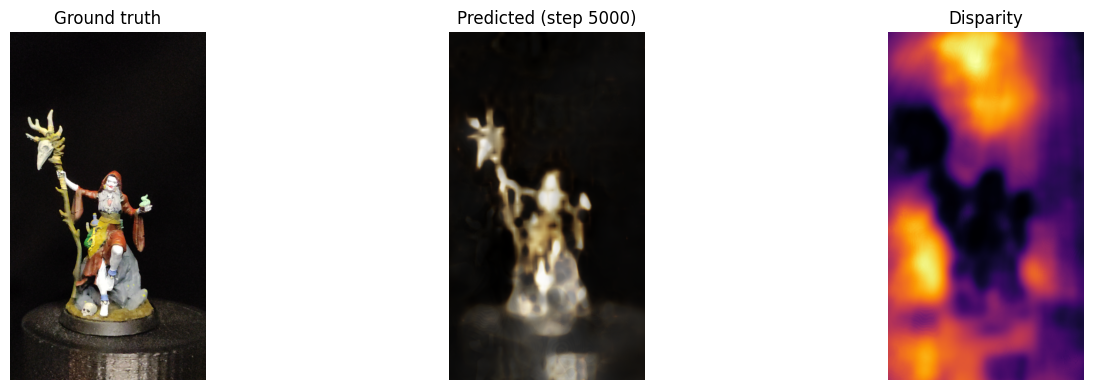

Training:   7%|▋         | 5000/70000 [40:55<607:08:26, 33.63s/it]

  ↳ Best checkpoint saved (PSNR=21.99)


Training:   8%|▊         | 5500/70000 [44:51<8:39:15,  2.07it/s]  

[  5500] loss=0.0139  PSNR=21.65 dB  lr=4.75e-04


Training:   9%|▊         | 6000/70000 [48:52<8:39:48,  2.05it/s] 

...

[  9500] loss=0.0098  PSNR=23.22 dB  lr=4.58e-04


Training:  14%|█▍        | 9999/70000 [1:20:14<7:45:24,  2.15it/s]

[ 10000] loss=0.0122  PSNR=22.31 dB  lr=4.56e-04


Training:  14%|█▍        | 9999/70000 [1:22:01<7:45:24,  2.15it/s]

  ↳ Val PSNR=22.63 dB


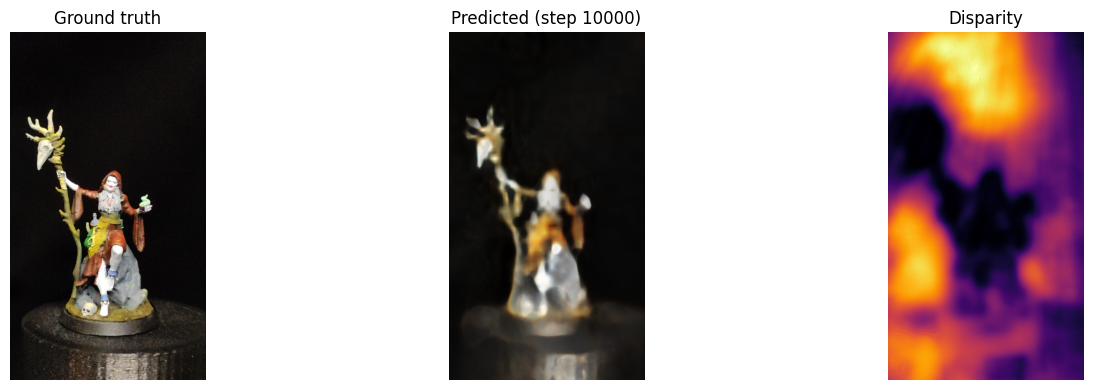

Training:  14%|█▍        | 10000/70000 [1:22:02<547:29:39, 32.85s/it]

  ↳ Best checkpoint saved (PSNR=22.63)


Training:  15%|█▌        | 10500/70000 [1:26:08<9:28:48,  1.74it/s]  

[ 10500] loss=0.0108  PSNR=22.83 dB  lr=4.54e-04


Training:  15%|█▌        | 10506/70000 [1:26:12<8:08:13,  2.03it/s] 


KeyboardInterrupt: 

In [15]:
images_t  = torch.Tensor(images).to(DEVICE)
poses_t   = torch.Tensor(poses).to(DEVICE)
rays_rgb_t = torch.Tensor(rays_rgb).to(DEVICE)

K_t    = torch.Tensor(K_np).to(DEVICE)
i_batch = 0

train_losses, train_psnrs = [], []
val_steps,    val_psnrs   = [], []
best_psnr = -float("inf")

global_step = 0
start       = 1

print("Starting training …")
for i in trange(start, N_ITERS + 1, desc="Training"):
    time0 = time.time()

    # ── Sample ray batch ─────────────────────────────────────────────────────
    batch    = rays_rgb_t[i_batch : i_batch + N_RAND]          # (B, 3, 3)
    batch    = torch.transpose(batch, 0, 1)                    # (3, B, 3)
    batch_rays, target_s = batch[:2], batch[2]                 # rays: (2, B, 3), targets: (B, 3)

    i_batch += N_RAND
    if i_batch >= rays_rgb_t.shape[0]:
        rand_idx  = torch.randperm(rays_rgb_t.shape[0])
        rays_rgb_t = rays_rgb_t[rand_idx]
        i_batch   = 0

    # ── Forward pass ─────────────────────────────────────────────────────────
    rgb, disp, acc, extras = render(
        H, W, K_t, chunk=CHUNK, rays=batch_rays,
        verbose=i < 10, retraw=True,
        **render_kwargs_train,
    )

    optimizer.zero_grad()
    img_loss = img2mse(rgb, target_s)
    loss     = img_loss
    psnr     = mse2psnr(img_loss)

    if 'rgb0' in extras:
        img_loss0 = img2mse(extras['rgb0'], target_s)
        loss      = loss + img_loss0

    loss.backward()
    optimizer.step()

    # ── LR decay ─────────────────────────────────────────────────────────────
    decay_rate  = 0.1
    decay_steps = LRATE_DECAY * 1000
    new_lrate   = LRATE * (decay_rate ** (global_step / decay_steps))
    for param_group in optimizer.param_groups:
        param_group['lr'] = new_lrate

    global_step += 1

    # ── Logging ───────────────────────────────────────────────────────────────
    if i % I_PRINT == 0:
        tqdm.write(f"[{i:6d}] loss={loss.item():.4f}  PSNR={psnr.item():.2f} dB  lr={new_lrate:.2e}")
        train_losses.append(loss.item())
        train_psnrs.append(psnr.item())

    # ── Validation preview ────────────────────────────────────────────────────
    if I_PREVIEW > 0 and i % I_PREVIEW == 0:
        model.eval(); model_fine.eval()
        with torch.no_grad():
            val_pose = poses_t[PREVIEW_IDX, :3, :4]
            rgb_val, disp_val, _, _ = render(
                H, W, K_t, chunk=CHUNK, c2w=val_pose,
                **render_kwargs_test,
            )
        rgb_np  = rgb_val.cpu().numpy().clip(0, 1)
        disp_np = disp_val.cpu().numpy()

        val_loss = np.mean((rgb_np - images[PREVIEW_IDX]) ** 2)
        val_psnr = float(-10 * np.log10(val_loss + 1e-10))
        val_steps.append(i)
        val_psnrs.append(val_psnr)
        tqdm.write(f"  ↳ Val PSNR={val_psnr:.2f} dB")

        # Inline visualisation
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        axes[0].imshow(images[PREVIEW_IDX].clip(0, 1))
        axes[0].set_title("Ground truth"); axes[0].axis("off")
        axes[1].imshow(rgb_np)
        axes[1].set_title(f"Predicted (step {i})"); axes[1].axis("off")
        disp_vis = (disp_np - disp_np.min()) / (disp_np.max() - disp_np.min() + 1e-6)
        axes[2].imshow(disp_vis, cmap="inferno")
        axes[2].set_title("Disparity"); axes[2].axis("off")
        plt.tight_layout(); plt.show()

        # Save preview + best checkpoint
        preview_path = os.path.join(OUTPUT_DIR, f"preview_{i:06d}.png")
        imageio.imwrite(preview_path, to8b(rgb_np))
        if val_psnr > best_psnr:
            best_psnr = val_psnr
            ckpt_path = os.path.join(OUTPUT_DIR, "nerf_pytorch_best.tar")
            torch.save({
                'global_step'             : global_step,
                'network_fn_state_dict'   : model.state_dict(),
                'network_fine_state_dict' : model_fine.state_dict(),
                'optimizer_state_dict'    : optimizer.state_dict(),
            }, ckpt_path)
            tqdm.write(f"  ↳ Best checkpoint saved (PSNR={best_psnr:.2f})") 

        model.train(); model_fine.train()

print(f"\nTraining complete. Best val PSNR: {best_psnr:.2f} dB")

## 8. Training Curves

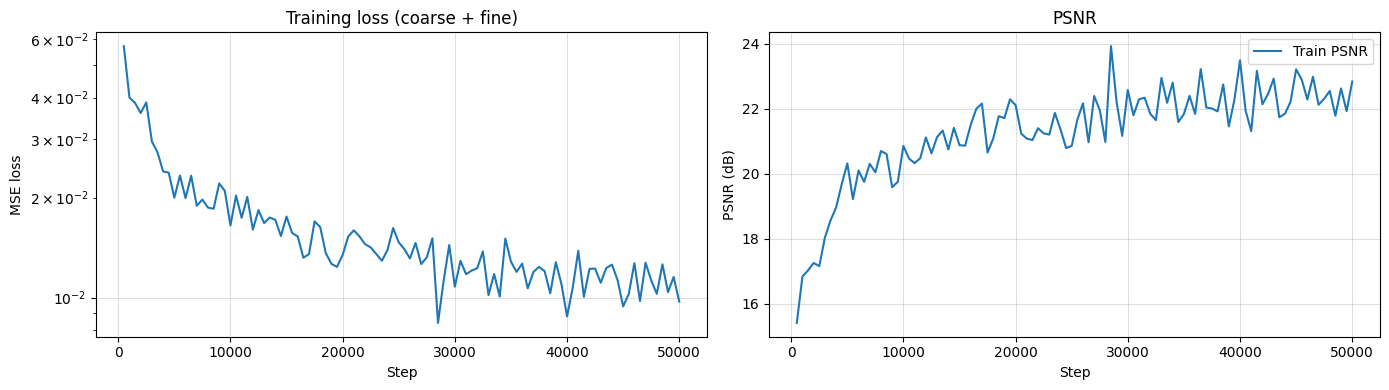

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

steps_logged = np.arange(1, len(train_losses) + 1) * I_PRINT
ax1.plot(steps_logged, train_losses)
ax1.set_xlabel("Step"); ax1.set_ylabel("MSE loss")
ax1.set_title("Training loss (coarse + fine)"); ax1.set_yscale("log"); ax1.grid(True, alpha=0.4)

ax2.plot(steps_logged, train_psnrs, label="Train PSNR")
if val_psnrs:
    ax2.plot(val_steps, val_psnrs, label="Val PSNR", marker='o', markersize=4)
ax2.set_xlabel("Step"); ax2.set_ylabel("PSNR (dB)")
ax2.set_title("PSNR"); ax2.legend(); ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

## 9. Render Novel-View Flyaround

Generate 120 spherical poses with `pose_spherical` and render each frame with `render_path`.  
Both RGB and disparity (depth) videos are saved to `OUTPUT_DIR`.

In [ ]:
# ── Spherical pose generator (from nerf-pytorch.py / nerf.ipynb) ─────────────
def trans_t(t):
    return torch.tensor([[1,0,0,0],[0,1,0,0],[0,0,1,t],[0,0,0,1]], dtype=torch.float32)

def rot_phi(phi):
    return torch.tensor([
        [1, 0, 0, 0],
        [0, np.cos(phi), -np.sin(phi), 0],
        [0, np.sin(phi),  np.cos(phi), 0],
        [0, 0, 0, 1]], dtype=torch.float32)

def rot_theta(th):
    return torch.tensor([
        [np.cos(th), 0, -np.sin(th), 0],
        [0, 1, 0, 0],
        [np.sin(th), 0,  np.cos(th), 0],
        [0, 0, 0, 1]], dtype=torch.float32)

def pose_spherical(theta, phi, radius):
    c2w = trans_t(radius)
    c2w = rot_phi(phi / 180. * np.pi) @ c2w
    c2w = rot_theta(theta / 180. * np.pi) @ c2w
    c2w = torch.tensor([[-1,0,0,0],[0,0,1,0],[0,1,0,0],[0,0,0,1]],
                       dtype=torch.float32) @ c2w
    return c2w

# ── Render ────────────────────────────────────────────────────────────────────
N_FRAMES    = 120
RENDER_PHI  = -30.0   # elevation angle
RENDER_RAD  = 1.5     # camera distance in normalised scene units

render_poses_fly = torch.stack(
    [pose_spherical(angle, RENDER_PHI, RENDER_RAD)
     for angle in np.linspace(-180, 180, N_FRAMES, endpoint=False)], 0
).to(DEVICE)

model.eval(); model_fine.eval()
with torch.no_grad():
    rgbs, disps = render_path(
        render_poses_fly, hwf, K_t, CHUNK, render_kwargs_test
    )

print(f"Rendered {rgbs.shape[0]} frames  |  shape={rgbs.shape}")

Rendering:   0%|          | 0/120 [00:00<?, ?it/s]c:\Users\gnoceras\Documents\GustavoPersonal\ReconstructionStudies\.venv\Lib\site-packages\torch\functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Rendering:   0%|          | 0/120 [00:04<?, ?it/s]


AcceleratorError: CUDA error: out of memory
Search for `cudaErrorMemoryAllocation' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
# ── Save RGB + disparity videos ───────────────────────────────────────────────
rgb_video_path   = os.path.join(OUTPUT_DIR, "nerf_pytorch_360_rgb.mp4")
depth_video_path = os.path.join(OUTPUT_DIR, "nerf_pytorch_360_depth.mp4")

def write_mp4(frames, out_path, fps=30):
    for codec in ["libx264", "mpeg4"]:
        try:
            with imageio.get_writer(
                out_path, format="FFMPEG", mode="I", fps=fps,
                codec=codec, pixelformat="yuv420p",
                macro_block_size=1, ffmpeg_log_level="error",
            ) as w:
                for fr in frames:
                    w.append_data(np.ascontiguousarray(fr, dtype=np.uint8))
            if os.path.getsize(out_path) > 0:
                print(f"Saved ({codec}) → {out_path}  [{os.path.getsize(out_path)/1e6:.2f} MB]")
                return
        except Exception as e:
            last_err = e
    raise RuntimeError(f"Failed to write {out_path}: {last_err}")

rgb_frames   = [to8b(r) for r in rgbs]
disp_max     = disps.max() if disps.max() > 0 else 1.0
disp_colored = [np.uint8(plt.cm.inferno(d / disp_max)[:, :, :3] * 255) for d in disps]

write_mp4(rgb_frames,   rgb_video_path)
write_mp4(disp_colored, depth_video_path)

# ── Quick inline preview (first frame) ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(rgb_frames[0]); axes[0].set_title("RGB frame 0"); axes[0].axis("off")
axes[1].imshow(disp_colored[0]); axes[1].set_title("Disparity frame 0 (inferno)"); axes[1].axis("off")
plt.tight_layout(); plt.show()